In [45]:
import os
import json
os.makedirs("../results", exist_ok=True)
from sklearn.model_selection import GridSearchCV
# --- Third-party libraries: numerical + plotting ---
import numpy as np                               # numerical computing (arrays, arange, hstack, etc.)
import matplotlib.pyplot as plt                  # plotting and visualization (figure, subplot, ax.plot, etc.)

# --- Standard library ---
import itertools                                 # utilities for efficient looping and combinations


# --- scikit-learn: models ---
from sklearn.tree import (
    DecisionTreeClassifier,                      # decision tree classifier
)

from sklearn.neighbors import (
    KNeighborsClassifier,                        # Nearest neighbors    
)

from sklearn.svm import (
    SVC,                                         # Support Vector Machines
)

from sklearn.linear_model import (
    LogisticRegression,                          # linear model: Logistic Regression
)

# --- Ensemble methods ---
from sklearn.ensemble import (
    VotingClassifier,                  # ensemble voting (hard / soft)
    BaggingClassifier,                 # bootstrap aggregating
    RandomForestClassifier,            # random forests
    ExtraTreesClassifier,              # extremely randomized trees
    StackingClassifier,                # stacking ensembles
    AdaBoostClassifier,                # adaptive boosting
    GradientBoostingClassifier,        # gradient boosting
)


# --- scikit-learn: model selection / evaluation ---
from sklearn.model_selection import (
    train_test_split,                            # train / test split
    cross_val_score,                             # evaluate model with cross-validation
    RepeatedStratifiedKFold,                     # repeated stratified k-fold splitting
)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.model_selection import GridSearchCV

### Load the data

In [2]:
x_train = np.load("../processed/X_train_norm.npy")
x_val   = np.load("../processed/X_val_norm.npy")
x_test  = np.load("../processed/X_test_norm.npy")

y_train = np.load("../processed/y_train.npy")
y_val   = np.load("../processed/y_val.npy")
y_test  = np.load("../processed/y_test.npy")

In [3]:
#Verification
print("X_train:", x_train.shape)
print("X_val:", x_val.shape)
print("X_test:", x_test.shape)

X_train: (54000, 784)
X_val: (6000, 784)
X_test: (10000, 784)


## 0 Helper function

In [5]:
def plot_res_mod(
    data_x,
    data_y,
    weights=None,
    regressor=None,
    is_list=False,
    labels=None,
    is_data_list=False,
    data_labels=None,
    func=None,
    data_style=None,
    xlabel="X",
    ylabel="Y",
    title=None,
    save_path=None,
):
    """
    Plot data points and optionally one or more fitted lines.

    Parameters
    ----------
    data_x : array-like or list of array-like
        X-values for data points. If `is_data_list` is True, this should be a list
        where each element corresponds to one dataset.
    data_y : array-like or list of array-like
        Y-values for data points, matching the structure of `data_x`.
    weights : tuple/list or list of tuples/lists, optional
        Linear model parameters. For a single model: (bias, slope).
        For multiple models (when `is_list` is True): list of (bias, slope) pairs.
    regressor : object, optional
        Model with a `.predict(X)` method (e.g. sklearn regressor). Plotted as a line.
        Expects `predict` to accept shape (n, 1). If it accepts 1D, we fall back.
    is_list : bool, default False
        Whether `weights` contains multiple (bias, slope) pairs.
    labels : list of str, optional
        Labels for the fitted lines. Automatically generated if not provided.
    is_data_list : bool, default False
        Whether `data_x` and `data_y` contain multiple datasets.
    data_labels : list of str, optional
        Labels for the datasets. Automatically generated if not provided.
    func : callable or list of callables, optional
        Transformation applied to x-values before using the weights. For multiple
        models, should be a list of callables. Defaults to identity.
    data_style : list[list[int|float,int|float]] or list[int|float,int|float], optional
        Styling for data points as [markersize, lw].
        Defaults to [[10, 0]] (points only, no connecting line).
    xlabel : str, default "X"
        Label of the x-axis.
    ylabel : str, default "Y"
        Label of the y-axis.
    title : str, optional
        Plot title.
    save_path : str, optional
        If provided, saves the figure to this path.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    xval = np.arange(0.0, 5.0, 0.01)  # domain for plotting fitted lines

    markers = ["o", "v", "s", "D", "X"]
    fig = plt.figure(figsize=(6, 6), dpi=100)
    ax = plt.subplot(111)

    # ----- data labels -----
    if data_labels is None:
        if is_data_list:
            data_labels = [f"data {i}" for i in range(1, len(data_x) + 1)]
        else:
            data_labels = ["data"]

    # ----- data style -----
    if data_style is None:
        data_style = [[10, 0] for _ in range(len(data_x) if is_data_list else 1)]

    # ----- plot data -----
    if is_data_list:
        for i in range(len(data_x)):
            ms, lw = data_style[i]
            ax.plot(
                data_x[i],
                data_y[i],
                label=data_labels[i],
                lw=lw,
                marker="o",
                markersize=ms,
            )
    else:
        ms, lw = data_style[0]
        ax.plot(
            data_x,
            data_y,
            label=data_labels[0],
            lw=lw,
            marker=markers[0],
            markersize=ms,
        )

    # ----- line labels -----
    if labels is None:
        if is_list and weights is not None:
            labels = [str(i) for i in range(1, len(weights) + 1)]
        else:
            labels = ["1"]

    # ----- functions -----
    if func is None:
        if is_list and weights is not None:
            func = [lambda x: x for _ in range(len(weights))]
        else:
            func = lambda x: x

    # ----- fitted lines from weights -----
    if weights is not None:
        if is_list:
            for i, w in enumerate(weights):
                ax.plot(
                    xval,
                    [w[1] * func[i](x) + w[0] for x in xval],
                    label=labels[i],
                    lw=3,
                )
        else:
            ax.plot(
                xval,
                [weights[1] * func(x) + weights[0] for x in xval],
                label=labels[0],
                lw=3,
            )

    # ----- fitted line from regressor -----
    if regressor is not None:
        try:
            yhat = regressor.predict(xval.reshape(-1, 1))
        except Exception:
            yhat = regressor.predict(xval)

        reg_label = labels[0] if labels is not None and len(labels) > 0 else "regressor"
        ax.plot(xval, yhat, label=reg_label, lw=3)

    ax.legend(loc="best", fancybox=True, fontsize=12)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    if title is not None:
        plt.title(title, fontsize=14)

    plt.tick_params(axis="both", which="major", labelsize=12)
    plt.grid(True)

    all_y = np.hstack(data_y) if is_data_list else np.asarray(data_y)
    y_width = all_y.max() - all_y.min()
    if y_width == 0:
        y_width = 1
    plt.ylim(all_y.min() - 0.1 * y_width, all_y.max() + 0.1 * y_width)

    all_x = np.hstack(data_x) if is_data_list else np.asarray(data_x)
    x_width = all_x.max() - all_x.min()
    if x_width == 0:
        x_width = 1
    plt.xlim(all_x.min() - 0.1 * x_width, all_x.max() + 0.1 * x_width)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

## 1 Single Methods

### 1.1 Decision tree

In [6]:
### Using validation set
score_train = []
score_val = []

### check score on VALIDATION data
for md in range(1, 16):
    ### train model
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    clf.fit(x_train,y_train)
    ### check score
    score_train.append(clf.score(x_train, y_train))
    score_val.append(clf.score(x_val, y_val))

    misclassified = (1 - score_val[-1]) * len(x_val)
    print("md={:02}".format(md),
          "score train: {:.6f}".format(score_train[-1]),
          "score val: {:.6f}".format(score_val[-1]),
          "misclassified:", int(misclassified))

md=01 score train: 0.198556 score val: 0.198333 misclassified: 4810
md=02 score train: 0.343130 score val: 0.338000 misclassified: 3971
md=03 score train: 0.488852 score val: 0.486167 misclassified: 3083
md=04 score train: 0.590556 score val: 0.592000 misclassified: 2448
md=05 score train: 0.675333 score val: 0.667667 misclassified: 1994
md=06 score train: 0.742185 score val: 0.734333 misclassified: 1594
md=07 score train: 0.793389 score val: 0.780667 misclassified: 1316
md=08 score train: 0.832093 score val: 0.815667 misclassified: 1106
md=09 score train: 0.870241 score val: 0.840667 misclassified: 956
md=10 score train: 0.904296 score val: 0.853667 misclassified: 877
md=11 score train: 0.932778 score val: 0.868000 misclassified: 792
md=12 score train: 0.952815 score val: 0.875667 misclassified: 745
md=13 score train: 0.968296 score val: 0.872833 misclassified: 762
md=14 score train: 0.978685 score val: 0.876333 misclassified: 742
md=15 score train: 0.985537 score val: 0.881667 miscla

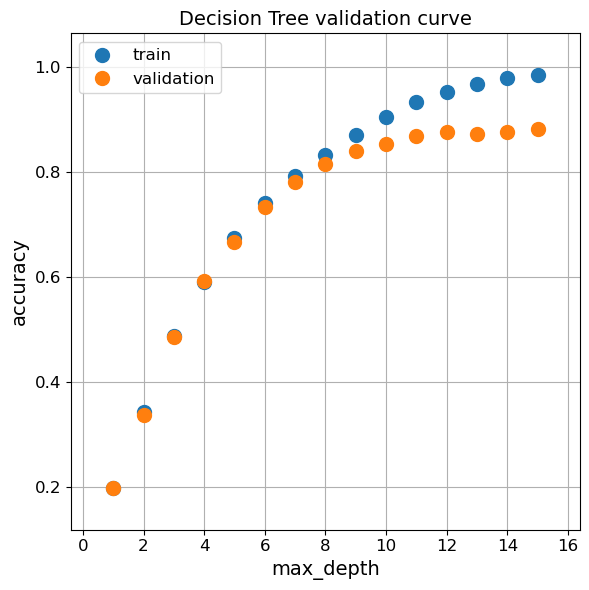

In [7]:
### plot result
max_depth = np.arange(1, len(score_train)+1, 1)
plot_res_mod(
    [max_depth, max_depth],
    [np.array(score_train), np.array(score_val)],
    is_data_list=True,
    data_labels=["train", "validation"],
    xlabel="max_depth",
    ylabel="accuracy",
    title="Decision Tree validation curve",
)

In [7]:
# Cross validation
kfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

for md in range(1, 20):
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    scores = cross_val_score(clf, x_train, y_train, cv=kfold)
    ##print(md, ": {:.6f}".format(scores.mean()))
    misclassified = (1 - scores.mean()) * len(x_val)
    print(f"max_depth={md} → CV score={scores.mean():.6f} → approx misclassified={int(misclassified)}")

max_depth=1 → CV score=0.195481 → approx misclassified=4827
max_depth=2 → CV score=0.338422 → approx misclassified=3969
max_depth=3 → CV score=0.472867 → approx misclassified=3162
max_depth=4 → CV score=0.606511 → approx misclassified=2360
max_depth=5 → CV score=0.674619 → approx misclassified=1952
max_depth=6 → CV score=0.732885 → approx misclassified=1602
max_depth=7 → CV score=0.778656 → approx misclassified=1328
max_depth=8 → CV score=0.812970 → approx misclassified=1122
max_depth=9 → CV score=0.837189 → approx misclassified=976
max_depth=10 → CV score=0.852096 → approx misclassified=887
max_depth=11 → CV score=0.860615 → approx misclassified=836
max_depth=12 → CV score=0.865256 → approx misclassified=808
max_depth=13 → CV score=0.867367 → approx misclassified=795
max_depth=14 → CV score=0.868541 → approx misclassified=788
max_depth=15 → CV score=0.868304 → approx misclassified=790
max_depth=16 → CV score=0.867689 → approx misclassified=793
max_depth=17 → CV score=0.866826 → approx

Result : validation data (md = 12), crossvalidation (md=14)

In [8]:
clf = DecisionTreeClassifier(max_depth=12, random_state=42)
clf.fit(x_train,y_train)
(1-clf.score(x_val,y_val))*len(x_val)

745.9999999999998

### 1.2 Knn

In [38]:
## validation set
score_train = []
score_val = []

### vary number for NN
for k in range(1, 20):
    ### setup of model
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(x_train, y_train)
    ### check score
    score_train.append(clf.score(x_train,y_train))
    score_val.append(clf.score(x_val,y_val))
    print("k={:02}".format(k), "score train: {:.6f}".format(score_train[-1]),
          "score val: {:.6f}".format(score_val[-1]))


k=01 score train: 1.000000 score val: 0.969167
k=02 score train: 0.985556 score val: 0.961833
k=03 score train: 0.986537 score val: 0.971333
k=04 score train: 0.982481 score val: 0.967333
k=05 score train: 0.981537 score val: 0.968333
k=06 score train: 0.978981 score val: 0.966000
k=07 score train: 0.978074 score val: 0.966167
k=08 score train: 0.976481 score val: 0.965833
k=09 score train: 0.975315 score val: 0.966500
k=10 score train: 0.973963 score val: 0.965167
k=11 score train: 0.973000 score val: 0.964333
k=12 score train: 0.971741 score val: 0.963667
k=13 score train: 0.971259 score val: 0.963833
k=14 score train: 0.970500 score val: 0.962833
k=15 score train: 0.969796 score val: 0.963833
k=16 score train: 0.968815 score val: 0.962833
k=17 score train: 0.968204 score val: 0.962333
k=18 score train: 0.967556 score val: 0.962167
k=19 score train: 0.966926 score val: 0.961333


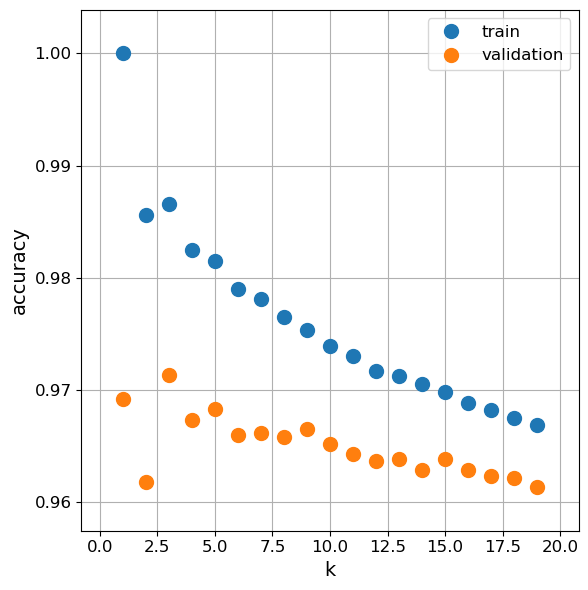

In [39]:
### plot result
nns = np.arange(1, len(score_train)+1, 1)
##plot_res([nns, nns], [np.array(score_train), np.array(score_val)], is_data_list=True)
plot_res_mod(
    [nns, nns],
    [score_train, score_val],
    is_data_list=True,
    data_labels=["train", "validation"],
    xlabel="k",
    ylabel="accuracy"
)

In [8]:
# cross validation
kfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=5)

for k in range(1, 20):
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, x_train, y_train, cv=kfold)
    print('k {:02}'.format(k), ": {:.6f}".format(scores.mean()))


k 01 : 0.970622
k 02 : 0.964085
k 03 : 0.970915
k 04 : 0.968904
k 05 : 0.969267
k 06 : 0.968500
k 07 : 0.967730
k 08 : 0.966678
k 09 : 0.966237
k 10 : 0.965533
k 11 : 0.965052
k 12 : 0.964274
k 13 : 0.963756
k 14 : 0.962874
k 15 : 0.962026
k 16 : 0.961696
k 17 : 0.961170
k 18 : 0.960326
k 19 : 0.959837
k 20 : 0.959456
k 21 : 0.958885
k 22 : 0.958189
k 23 : 0.957763
k 24 : 0.956989
k 25 : 0.956770
k 26 : 0.955881
k 27 : 0.955337
k 28 : 0.955456
k 29 : 0.954404
k 30 : 0.953774
k 31 : 0.953244
k 32 : 0.952648
k 33 : 0.952222
k 34 : 0.951874
k 35 : 0.951526
k 36 : 0.951230
k 37 : 0.950819
k 38 : 0.950426
k 39 : 0.949959
k 40 : 0.949289


validation set gives = 3, cross validation gives = 3 also

In [12]:
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(x_train,y_train)
(1-clf.score(x_val,y_val))*len(x_val)

171.99999999999972

### 1.3 SVM

In [10]:
### setup of SVM model
clf = SVC(probability=True)
clf.fit(x_train,y_train)
(1-clf.score(x_val,y_val))*len(x_val)

126.00000000000011

### 1.4 Logistic regression

In [13]:
### setup of LogReg model
clf = LogisticRegression(max_iter=1000)
clf.fit(x_train,y_train)
(1-clf.score(x_val,y_val))*len(x_val)

469.0000000000003

### 1.5 Compare all 4 models 

In [13]:
clf1 = DecisionTreeClassifier(max_depth=12, random_state=42)
clf2 = KNeighborsClassifier(n_neighbors=3)
clf3 = SVC(probability=True)
clf4 = LogisticRegression(max_iter=1000)

clf1.fit(x_train,y_train)
clf2.fit(x_train,y_train)
clf3.fit(x_train,y_train)
clf4.fit(x_train,y_train)

print((1-clf1.score(x_val,y_val))*len(x_val))
print((1-clf2.score(x_val,y_val))*len(x_val))
print((1-clf3.score(x_val,y_val))*len(x_val))
print((1-clf4.score(x_val,y_val))*len(x_val))

745.9999999999998
171.99999999999972
126.00000000000011
469.0000000000003


# Ensemble methods

# 1 Voting Classifier

## 1.1 Hard Voting

In [18]:
estimators = [('tree', clf1), ('kNN', clf2), ('SVM', clf3), ('LR', clf4)]

In [19]:
### hard 
for sub_est in itertools.combinations(range(4), 3):

    selected_estimators = [estimators[i] for i in sub_est]
    names = [estimators[i][0] for i in sub_est]

    mclf = VotingClassifier(
        estimators=selected_estimators,
        voting="hard"
    )

    mclf.fit(x_train, y_train)

    score = mclf.score(x_val, y_val)
    misclassified = int((1 - score) * len(x_val))

    print(f"methods: {names} | misclassified: {misclassified} | score: {score:.6f}")

methods: ['tree', 'kNN', 'SVM'] | misclassified: 146 | score: 0.975500
methods: ['tree', 'kNN', 'LR'] | misclassified: 268 | score: 0.955167
methods: ['tree', 'SVM', 'LR'] | misclassified: 255 | score: 0.957333
methods: ['kNN', 'SVM', 'LR'] | misclassified: 145 | score: 0.975833


## 1.2 Soft Voting

In [20]:
### soft 
for num_methods in range(1, 5):
    for sub_est in itertools.combinations(range(4), num_methods):

        selected_estimators = [estimators[i] for i in sub_est]
        names = [estimators[i][0] for i in sub_est]

        mclf = VotingClassifier(
            estimators=selected_estimators,
            voting="soft"
        )

        mclf.fit(x_train, y_train)

        score = mclf.score(x_val, y_val)
        misclassified = int((1 - score) * len(x_val))

        print(f"methods: {names} | wrong samples: {misclassified} | score: {score:.6f}")

methods: ['tree'] | wrong samples: 756 | score: 0.873833
methods: ['kNN'] | wrong samples: 171 | score: 0.971333
methods: ['SVM'] | wrong samples: 127 | score: 0.978833
methods: ['LR'] | wrong samples: 469 | score: 0.921833
methods: ['tree', 'kNN'] | wrong samples: 340 | score: 0.943167
methods: ['tree', 'SVM'] | wrong samples: 454 | score: 0.924167
methods: ['tree', 'LR'] | wrong samples: 608 | score: 0.898667
methods: ['kNN', 'SVM'] | wrong samples: 126 | score: 0.979000
methods: ['kNN', 'LR'] | wrong samples: 194 | score: 0.967500
methods: ['SVM', 'LR'] | wrong samples: 198 | score: 0.967000
methods: ['tree', 'kNN', 'SVM'] | wrong samples: 135 | score: 0.977333
methods: ['tree', 'kNN', 'LR'] | wrong samples: 242 | score: 0.959667
methods: ['tree', 'SVM', 'LR'] | wrong samples: 222 | score: 0.963000
methods: ['kNN', 'SVM', 'LR'] | wrong samples: 145 | score: 0.975833
methods: ['tree', 'kNN', 'SVM', 'LR'] | wrong samples: 157 | score: 0.973667


## 1.3 Weighted Soft Voting

In [22]:
### weighted 
weight_sets = [
    [1,3,4,2],
    [1,4,5,2],
    [1,3,2,2],
    [1,3,5,2]
]
for w in weight_sets:
    
    mclf = VotingClassifier(
        estimators=estimators,
        voting="soft",
        weights=w
    )

    mclf.fit(x_train,y_train)

    score = mclf.score(x_val,y_val)
    misclassified = int((1-score)*len(x_val))

    print(f"weights: {w} | wrong samples: {misclassified} | score: {score:.6f}")

weights: [1, 3, 4, 2] | wrong samples: 132 | score: 0.978000
weights: [1, 4, 5, 2] | wrong samples: 131 | score: 0.978167
weights: [1, 3, 2, 2] | wrong samples: 140 | score: 0.976500
weights: [1, 3, 5, 2] | wrong samples: 128 | score: 0.978500


# 2 Bagging

## 2.1 Bagging: Decision tree

In [35]:
#n_estimators=50 (random boostrap)
for md in range(1, 20):
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    mclf = BaggingClassifier(estimator=clf,n_estimators=50, random_state=42)
    mclf.fit(x_train, y_train)
    
    misclassified = (1-mclf.score(x_val,y_val))*len(x_val)
    print(f"max_depth={md} → misclassified: {misclassified:.0f} → score: {mclf.score(x_val,y_val):.4f}")


max_depth=1 → misclassified: 3853 → score: 0.3578
max_depth=2 → misclassified: 3472 → score: 0.4213
max_depth=3 → misclassified: 2476 → score: 0.5873
max_depth=4 → misclassified: 1780 → score: 0.7033
max_depth=5 → misclassified: 1318 → score: 0.7803
max_depth=6 → misclassified: 970 → score: 0.8383
max_depth=7 → misclassified: 733 → score: 0.8778
max_depth=8 → misclassified: 596 → score: 0.9007
max_depth=9 → misclassified: 472 → score: 0.9213
max_depth=10 → misclassified: 387 → score: 0.9355
max_depth=11 → misclassified: 344 → score: 0.9427
max_depth=12 → misclassified: 313 → score: 0.9478
max_depth=13 → misclassified: 285 → score: 0.9525
max_depth=14 → misclassified: 284 → score: 0.9527
max_depth=15 → misclassified: 276 → score: 0.9540
max_depth=16 → misclassified: 276 → score: 0.9540
max_depth=17 → misclassified: 268 → score: 0.9553
max_depth=18 → misclassified: 277 → score: 0.9538
max_depth=19 → misclassified: 270 → score: 0.9550


## 2.2 Bagging: KNN

In [37]:
### setup of kNNs with varying number of neighbors
for k in [1,3,5,15]:
    clf = KNeighborsClassifier(n_neighbors=k)
    mclf = BaggingClassifier(estimator=clf,n_estimators=50, random_state=42)
    mclf.fit(x_train, y_train)
    
    misclassified = (1-mclf.score(x_val,y_val))*len(x_val)
    print(f"max_depth={k} → misclassified: {misclassified:.0f} → score: {mclf.score(x_val,y_val):.4f}")

max_depth=1 → misclassified: 184 → score: 0.9693
max_depth=3 → misclassified: 166 → score: 0.9723
max_depth=5 → misclassified: 182 → score: 0.9697
max_depth=15 → misclassified: 214 → score: 0.9643


### Bagging __only__ on Decision Tree

In [18]:
clf1 = DecisionTreeClassifier(max_depth=12, random_state=42)
clf2 = KNeighborsClassifier(n_neighbors=3)
clf3 = SVC(probability=True)
clf4 = LogisticRegression(max_iter=1000)

n_estimators = 50
mclf1 = BaggingClassifier(estimator=clf1, n_estimators=n_estimators, random_state=42)

mclf1.fit(x_train, y_train)
misclassified = (1-mclf1.score(x_val,y_val))*len(x_val)
print(f"Tree → misclassified: {misclassified:.0f} → score: {mclf1.score(x_val,y_val):.4f}")

clf2.fit(x_train, y_train)
misclassified = (1-clf2.score(x_val,y_val))*len(x_val)
print(f"KNN → misclassified: {misclassified:.0f} → score: {clf2.score(x_val,y_val):.4f}")

clf3.fit(x_train, y_train)
misclassified = (1-clf3.score(x_val,y_val))*len(x_val)
print(f"SVC → misclassified: {misclassified:.0f} → score: {clf3.score(x_val,y_val):.4f}")

clf4.fit(x_train, y_train)
misclassified = (1-clf4.score(x_val,y_val))*len(x_val)
print(f"LR → misclassified: {misclassified:.0f} → score: {clf4.score(x_val,y_val):.4f}")

estimators = [('tree', mclf1), ('kNN', clf2), ('SVM', clf3), ('LR', clf4)]

Tree → misclassified: 318 → score: 0.9470
KNN → misclassified: 172 → score: 0.9713
SVC → misclassified: 126 → score: 0.9790
LR → misclassified: 469 → score: 0.9218


## 2.3 Bagging ( __only__ on Decision Tree) + Voting

### 2.3.1 Bagging + Soft Voting

In [19]:
### soft 
for num_methods in range(1, 5):
    for sub_est in itertools.combinations(range(4), num_methods):

        selected_estimators = [estimators[i] for i in sub_est]
        names = [estimators[i][0] for i in sub_est]

        mclf = VotingClassifier(
            estimators=selected_estimators,
            voting="soft"
        )

        mclf.fit(x_train, y_train)

        score = mclf.score(x_val, y_val)
        misclassified = int((1 - score) * len(x_val))

        print(f"methods: {names} | wrong samples: {misclassified} | score: {score:.6f}")

methods: ['tree'] | wrong samples: 313 | score: 0.947833
methods: ['kNN'] | wrong samples: 171 | score: 0.971333
methods: ['SVM'] | wrong samples: 127 | score: 0.978833
methods: ['LR'] | wrong samples: 469 | score: 0.921833
methods: ['tree', 'kNN'] | wrong samples: 161 | score: 0.973167
methods: ['tree', 'SVM'] | wrong samples: 126 | score: 0.979000
methods: ['tree', 'LR'] | wrong samples: 350 | score: 0.941667
methods: ['kNN', 'SVM'] | wrong samples: 127 | score: 0.978667
methods: ['kNN', 'LR'] | wrong samples: 194 | score: 0.967500
methods: ['SVM', 'LR'] | wrong samples: 197 | score: 0.967167
methods: ['tree', 'kNN', 'SVM'] | wrong samples: 122 | score: 0.979500
methods: ['tree', 'kNN', 'LR'] | wrong samples: 188 | score: 0.968500
methods: ['tree', 'SVM', 'LR'] | wrong samples: 183 | score: 0.969333
methods: ['kNN', 'SVM', 'LR'] | wrong samples: 145 | score: 0.975833
methods: ['tree', 'kNN', 'SVM', 'LR'] | wrong samples: 139 | score: 0.976667


### 2.3.2 Bagging + Weighted Soft Voting

In [21]:
### weighted 
weight_sets = [
    [2,3,4,1],
    [2,4,5,1],
    [1,3,4,1],
    [2,3,5,1]
]
for w in weight_sets:
    
    mclf = VotingClassifier(
        estimators=estimators,
        voting="soft",
        weights=w
    )

    mclf.fit(x_train,y_train)

    score = mclf.score(x_val,y_val)
    misclassified = int((1-score)*len(x_val))

    print(f"weights: {w} | wrong samples: {misclassified} | score: {score:.6f}")

weights: [2, 3, 5, 1] | wrong samples: 122 | score: 0.979500


## 2.4 Random Forest

In [12]:
for md in range(1, 19):
    mclf = RandomForestClassifier(n_estimators=10, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3454 → score: 0.424333
max_depth=2 → misclassified: 2488 → score: 0.585333
max_depth=3 → misclassified: 1943 → score: 0.676167
max_depth=4 → misclassified: 1299 → score: 0.783500
max_depth=5 → misclassified: 1079 → score: 0.820167
max_depth=6 → misclassified: 907 → score: 0.848833
max_depth=7 → misclassified: 728 → score: 0.878667
max_depth=8 → misclassified: 638 → score: 0.893667
max_depth=9 → misclassified: 528 → score: 0.912000
max_depth=10 → misclassified: 447 → score: 0.925500
max_depth=11 → misclassified: 398 → score: 0.933667
max_depth=12 → misclassified: 384 → score: 0.936000
max_depth=13 → misclassified: 375 → score: 0.937500
max_depth=14 → misclassified: 345 → score: 0.942500
max_depth=15 → misclassified: 353 → score: 0.941167
max_depth=16 → misclassified: 337 → score: 0.943833
max_depth=17 → misclassified: 346 → score: 0.942333
max_depth=18 → misclassified: 343 → score: 0.942833


In [22]:
for md in range(1, 19):
    mclf = RandomForestClassifier(n_estimators=50, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3066 → score: 0.489000
max_depth=2 → misclassified: 2260 → score: 0.623333
max_depth=3 → misclassified: 1757 → score: 0.707167
max_depth=4 → misclassified: 1159 → score: 0.806833
max_depth=5 → misclassified: 892 → score: 0.851333
max_depth=6 → misclassified: 723 → score: 0.879500
max_depth=7 → misclassified: 557 → score: 0.907167
max_depth=8 → misclassified: 487 → score: 0.918833
max_depth=9 → misclassified: 417 → score: 0.930500
max_depth=10 → misclassified: 344 → score: 0.942667
max_depth=11 → misclassified: 311 → score: 0.948167
max_depth=12 → misclassified: 273 → score: 0.954500
max_depth=13 → misclassified: 261 → score: 0.956500
max_depth=14 → misclassified: 251 → score: 0.958167
max_depth=15 → misclassified: 237 → score: 0.960500
max_depth=16 → misclassified: 227 → score: 0.962167
max_depth=17 → misclassified: 220 → score: 0.963333
max_depth=18 → misclassified: 211 → score: 0.964833


In [13]:
for md in range(1, 19):
    mclf = RandomForestClassifier(n_estimators=100, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 2892 → score: 0.518000
max_depth=2 → misclassified: 2153 → score: 0.641167
max_depth=3 → misclassified: 1656 → score: 0.724000
max_depth=4 → misclassified: 1106 → score: 0.815667
max_depth=5 → misclassified: 890 → score: 0.851667
max_depth=6 → misclassified: 674 → score: 0.887667
max_depth=7 → misclassified: 545 → score: 0.909167
max_depth=8 → misclassified: 470 → score: 0.921667
max_depth=9 → misclassified: 400 → score: 0.933333
max_depth=10 → misclassified: 339 → score: 0.943500
max_depth=11 → misclassified: 305 → score: 0.949167
max_depth=12 → misclassified: 265 → score: 0.955833
max_depth=13 → misclassified: 244 → score: 0.959333
max_depth=14 → misclassified: 234 → score: 0.961000
max_depth=15 → misclassified: 218 → score: 0.963667
max_depth=16 → misclassified: 212 → score: 0.964667
max_depth=17 → misclassified: 209 → score: 0.965167
max_depth=18 → misclassified: 204 → score: 0.966000


In [14]:
for md in range(1, 19):
    mclf = RandomForestClassifier(n_estimators=1000, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 2754 → score: 0.541000
max_depth=2 → misclassified: 2186 → score: 0.635667
max_depth=3 → misclassified: 1499 → score: 0.750167
max_depth=4 → misclassified: 1089 → score: 0.818500
max_depth=5 → misclassified: 836 → score: 0.860667
max_depth=6 → misclassified: 653 → score: 0.891167
max_depth=7 → misclassified: 535 → score: 0.910833
max_depth=8 → misclassified: 449 → score: 0.925167
max_depth=9 → misclassified: 381 → score: 0.936500
max_depth=10 → misclassified: 324 → score: 0.946000
max_depth=11 → misclassified: 289 → score: 0.951833
max_depth=12 → misclassified: 260 → score: 0.956667
max_depth=13 → misclassified: 245 → score: 0.959167
max_depth=14 → misclassified: 223 → score: 0.962833
max_depth=15 → misclassified: 217 → score: 0.963833
max_depth=16 → misclassified: 208 → score: 0.965333
max_depth=17 → misclassified: 193 → score: 0.967833
max_depth=18 → misclassified: 193 → score: 0.967833


## 2.5 ExtraTrees

In [15]:
for md in range(1, 19):
    mclf = ExtraTreesClassifier(n_estimators=10, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3448 → score: 0.425333
max_depth=2 → misclassified: 2787 → score: 0.535500
max_depth=3 → misclassified: 2231 → score: 0.628167
max_depth=4 → misclassified: 1726 → score: 0.712333
max_depth=5 → misclassified: 1302 → score: 0.783000
max_depth=6 → misclassified: 1075 → score: 0.820833
max_depth=7 → misclassified: 914 → score: 0.847667
max_depth=8 → misclassified: 734 → score: 0.877667
max_depth=9 → misclassified: 645 → score: 0.892500
max_depth=10 → misclassified: 546 → score: 0.909000
max_depth=11 → misclassified: 472 → score: 0.921333
max_depth=12 → misclassified: 420 → score: 0.930000
max_depth=13 → misclassified: 400 → score: 0.933333
max_depth=14 → misclassified: 391 → score: 0.934833
max_depth=15 → misclassified: 361 → score: 0.939833
max_depth=16 → misclassified: 337 → score: 0.943833
max_depth=17 → misclassified: 325 → score: 0.945833
max_depth=18 → misclassified: 324 → score: 0.946000


In [23]:
## increase number of estimators 
for md in range(1, 19):
    mclf = ExtraTreesClassifier(n_estimators=50, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3164 → score: 0.472667
max_depth=2 → misclassified: 2252 → score: 0.624667
max_depth=3 → misclassified: 1880 → score: 0.686667
max_depth=4 → misclassified: 1402 → score: 0.766333
max_depth=5 → misclassified: 1082 → score: 0.819667
max_depth=6 → misclassified: 823 → score: 0.862833
max_depth=7 → misclassified: 687 → score: 0.885500
max_depth=8 → misclassified: 569 → score: 0.905167
max_depth=9 → misclassified: 488 → score: 0.918667
max_depth=10 → misclassified: 436 → score: 0.927333
max_depth=11 → misclassified: 343 → score: 0.942833
max_depth=12 → misclassified: 326 → score: 0.945667
max_depth=13 → misclassified: 281 → score: 0.953167
max_depth=14 → misclassified: 263 → score: 0.956167
max_depth=15 → misclassified: 262 → score: 0.956333
max_depth=16 → misclassified: 237 → score: 0.960500
max_depth=17 → misclassified: 216 → score: 0.964000
max_depth=18 → misclassified: 218 → score: 0.963667


In [16]:
## increase number of estimators 
for md in range(1, 19):
    mclf = ExtraTreesClassifier(n_estimators=100, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 3020 → score: 0.496667
max_depth=2 → misclassified: 2234 → score: 0.627667
max_depth=3 → misclassified: 1848 → score: 0.692000
max_depth=4 → misclassified: 1354 → score: 0.774333
max_depth=5 → misclassified: 1036 → score: 0.827333
max_depth=6 → misclassified: 797 → score: 0.867167
max_depth=7 → misclassified: 663 → score: 0.889500
max_depth=8 → misclassified: 538 → score: 0.910333
max_depth=9 → misclassified: 452 → score: 0.924667
max_depth=10 → misclassified: 400 → score: 0.933333
max_depth=11 → misclassified: 342 → score: 0.943000
max_depth=12 → misclassified: 301 → score: 0.949833
max_depth=13 → misclassified: 274 → score: 0.954333
max_depth=14 → misclassified: 254 → score: 0.957667
max_depth=15 → misclassified: 239 → score: 0.960167
max_depth=16 → misclassified: 215 → score: 0.964167
max_depth=17 → misclassified: 197 → score: 0.967167
max_depth=18 → misclassified: 202 → score: 0.966333


In [17]:
## increase number of estimators 
for md in range(1, 19):
    mclf = ExtraTreesClassifier(n_estimators=1000, max_depth=md, random_state=42)
    mclf.fit(x_train, y_train)

    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")

max_depth=1 → misclassified: 2843 → score: 0.526167
max_depth=2 → misclassified: 2193 → score: 0.634500
max_depth=3 → misclassified: 1669 → score: 0.721833
max_depth=4 → misclassified: 1292 → score: 0.784667
max_depth=5 → misclassified: 979 → score: 0.836833
max_depth=6 → misclassified: 776 → score: 0.870667
max_depth=7 → misclassified: 621 → score: 0.896500
max_depth=8 → misclassified: 508 → score: 0.915333
max_depth=9 → misclassified: 445 → score: 0.925833
max_depth=10 → misclassified: 382 → score: 0.936333
max_depth=11 → misclassified: 333 → score: 0.944500
max_depth=12 → misclassified: 298 → score: 0.950333
max_depth=13 → misclassified: 260 → score: 0.956667
max_depth=14 → misclassified: 234 → score: 0.961000
max_depth=15 → misclassified: 212 → score: 0.964667
max_depth=16 → misclassified: 207 → score: 0.965500
max_depth=17 → misclassified: 189 → score: 0.968500
max_depth=18 → misclassified: 189 → score: 0.968500


# 3 Boosting

## 3.1 AdaBoost

Work with weak lerner

In [24]:
### setup of model
n_estimators = 10

for md in [1, 2, 4, 8, 10, 12, 14]:
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    mclf = AdaBoostClassifier(estimator=clf, n_estimators=n_estimators, random_state=42)
    mclf.fit(x_train, y_train)
    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")


max_depth=1 → misclassified: 4017 → score: 0.330500
max_depth=2 → misclassified: 2390 → score: 0.601667
max_depth=4 → misclassified: 1267 → score: 0.788833
max_depth=8 → misclassified: 508 → score: 0.915333
max_depth=10 → misclassified: 435 → score: 0.927500
max_depth=12 → misclassified: 346 → score: 0.942333
max_depth=14 → misclassified: 333 → score: 0.944500


In [26]:
### setup of model
n_estimators = 50

for md in [1, 2, 4, 8, 10, 12, 14]:
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    mclf = AdaBoostClassifier(estimator=clf, n_estimators=n_estimators, random_state=42)
    mclf.fit(x_train, y_train)
    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")


max_depth=1 → misclassified: 2145 → score: 0.642500
max_depth=2 → misclassified: 1298 → score: 0.783667
max_depth=4 → misclassified: 738 → score: 0.877000
max_depth=8 → misclassified: 297 → score: 0.950500
max_depth=10 → misclassified: 249 → score: 0.958500
max_depth=12 → misclassified: 211 → score: 0.964833
max_depth=14 → misclassified: 203 → score: 0.966167


In [25]:
### setup of model
n_estimators = 100

for md in [1, 2, 4, 8, 10, 12, 14]:
    clf = DecisionTreeClassifier(max_depth=md, random_state=42)
    mclf = AdaBoostClassifier(estimator=clf, n_estimators=n_estimators, random_state=42)
    mclf.fit(x_train, y_train)
    print(f"max_depth={md} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {mclf.score(x_val,y_val):.6f}")


max_depth=1 → misclassified: 1532 → score: 0.744667
max_depth=2 → misclassified: 1111 → score: 0.814833
max_depth=4 → misclassified: 589 → score: 0.901833
max_depth=8 → misclassified: 229 → score: 0.961833
max_depth=10 → misclassified: 199 → score: 0.966833
max_depth=12 → misclassified: 188 → score: 0.968667
max_depth=14 → misclassified: 191 → score: 0.968167


Fixing max_depth=12 and varying the number of estimators:

n_estimators=1 → misclassified: 761 → score: 0.873167
n_estimators=10 → misclassified: 346 → score: 0.942333
n_estimators=50 → misclassified: 211 → score: 0.964833
n_estimators=100 → misclassified: 188 → score: 0.968667
n_estimators=500 → misclassified: 162 → score: 0.973000


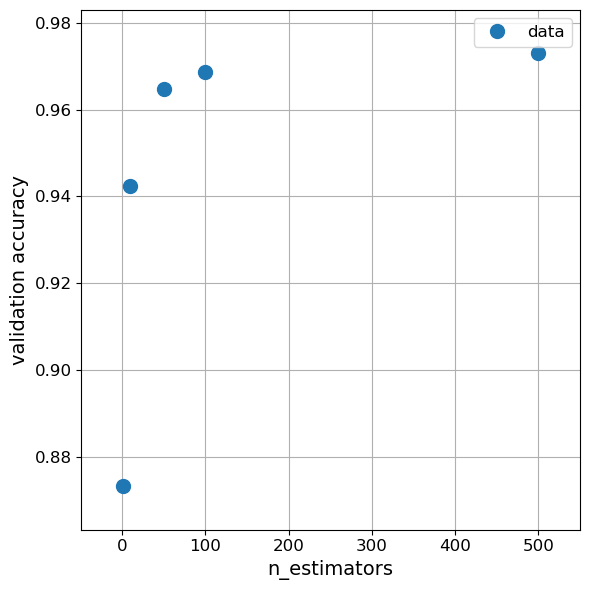

In [32]:
score_val = []

estimators_list = [1, 10, 50, 100, 500]
clf = DecisionTreeClassifier(max_depth=12, random_state=42)

for n_estimators in estimators_list:

    mclf = AdaBoostClassifier(
        estimator=clf,
        n_estimators=n_estimators,
        random_state=42
    )

    mclf.fit(x_train, y_train)

    score = mclf.score(x_val, y_val)
    score_val.append(score)
    print(f"n_estimators={n_estimators} → misclassified: {(1-mclf.score(x_val,y_val))*len(x_val):.0f} → score: {score:.6f}")

plot_res_mod(
    estimators_list,
    np.array(score_val),
    xlabel="n_estimators",
    ylabel="validation accuracy"
)

Fixing n_estim =100, md=12, trying different learning_rate:

learning_rate=0.1 → misclassified: 151 → score: 0.974667
learning_rate=0.5 → misclassified: 156 → score: 0.974000
learning_rate=1 → misclassified: 187 → score: 0.968667
learning_rate=1.5 → misclassified: 218 → score: 0.963500
learning_rate=2 → misclassified: 229 → score: 0.961833


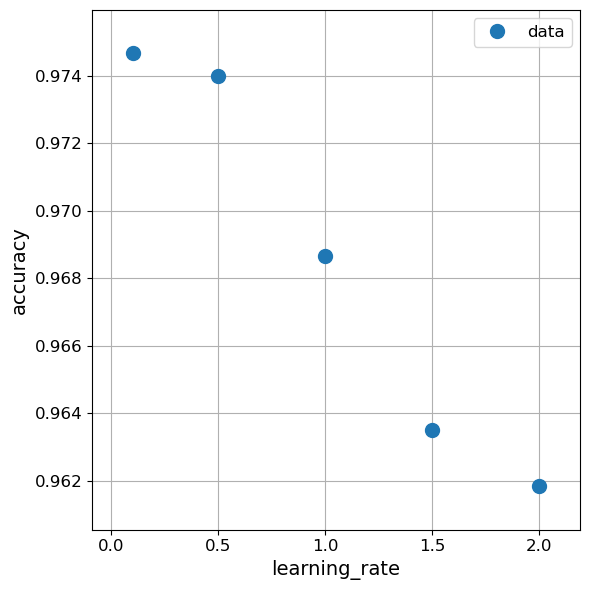

In [33]:
#fixing n_estim =100, md=12, trying different learning_rate
score_val = []
clf = DecisionTreeClassifier(max_depth=12, random_state=42)

learning_rates = [0.1, 0.5, 1, 1.5, 2]

for lr in learning_rates:

    mclf = AdaBoostClassifier(
        estimator=clf,
        n_estimators=100,
        learning_rate=lr,
        random_state=42
    )

    mclf.fit(x_train, y_train)
    
    score = mclf.score(x_val, y_val)
    score_val.append(score)
    misclassified = int((1 - score) * len(x_val))
    print(f"learning_rate={lr} → misclassified: {misclassified} → score: {score:.6f}")
    

plot_res_mod(
    learning_rates,
    np.array(score_val),
    xlabel="learning_rate",
    ylabel="accuracy"
)

## 3.2 Gradient Boosting Classifier

In [41]:
max_dep_list = [1, 5, 8, 10, 12, 15]

for md in max_dep_list:
    clf = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=md,
        random_state=42)
    clf.fit(x_train, y_train)
    score = clf.score(x_val, y_val)
    print(f"md={md} → misclassified: {(1-clf.score(x_val,y_val))*len(x_val):.0f} → score: {score:.6f}")


md=1 → misclassified: 891 → score: 0.851500
md=5 → misclassified: 214 → score: 0.964333
md=8 → misclassified: 180 → score: 0.970000
md=10 → misclassified: 189 → score: 0.968500
md=12 → misclassified: 195 → score: 0.967500
md=15 → misclassified: 216 → score: 0.964000


Fixing max_depth=12 and trying different n_estimators:

n_estimators=1 → misclassified: 954 → score: 0.841000
n_estimators=10 → misclassified: 458 → score: 0.923667
n_estimators=50 → misclassified: 261 → score: 0.956500


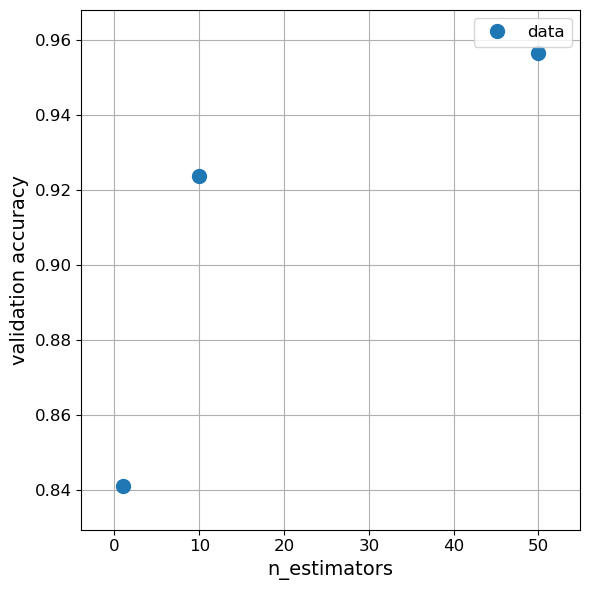

In [43]:
score_val = []

estimators_list = [1, 10, 50]

for n_estimators in estimators_list:
    clf = GradientBoostingClassifier(
        n_estimators=n_estimators,
        random_state=42,
        max_depth=12,
    )

    clf.fit(x_train, y_train)

    score = clf.score(x_val, y_val)
    score_val.append(score)
    print(f"n_estimators={n_estimators} → misclassified: {(1-clf.score(x_val,y_val))*len(x_val):.0f} → score: {score:.6f}")

plot_res_mod(
    estimators_list,
    np.array(score_val),
    xlabel="n_estimators",
    ylabel="validation accuracy"
)

Fixing n_estim =100, md=12, trying different learning_rate:

In [51]:
#fixing n_estim =100, md=12, trying different learning_rate
score_val = []

learning_rates = [0.1, 0.5, 1, 1.5]

for lr in learning_rates:

    clf = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=lr,
        random_state=42,
        max_depth=12,
    )

    clf.fit(x_train, y_train)
    
    score = clf.score(x_val, y_val)
    score_val.append(score)
    misclassified = int((1 - score) * len(x_val))
    print(f"learning_rate={lr} → misclassified: {misclassified} → score: {score:.6f}")

learning_rate=0.1 → misclassified: 194 → score: 0.967500
learning_rate=0.5 → misclassified: 219 → score: 0.963333
learning_rate=1 → misclassified: 927 → score: 0.845333


KeyboardInterrupt: 

### Comparing Adaboost and Gradient Boosting 

Trade-off between learning_rate and n_estimators (with max-depth=12)

In [ ]:
n_estimators_list = [10, 50, 100, 200]
learning_rates = [0.05, 0.1, 0.5, 1]

base_tree = DecisionTreeClassifier(max_depth=12, random_state=42)

models = {
    "AdaBoost": lambda n, lr: AdaBoostClassifier(
        estimator=base_tree,
        n_estimators=n,
        learning_rate=lr,
        random_state=42
    ),
    
    "GradientBoosting": lambda n, lr: GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=lr,
        max_depth=12,
        random_state=42
    )
}

for model_name, model_func in models.items():
    for n_est in n_estimators_list:
        for lr in learning_rates:

            model = model_func(n_est, lr)
            model.fit(x_train, y_train)

            score = model.score(x_val, y_val)
            wrong = int((1 - score) * len(x_val))

            print(
                f"{model_name} | "
                f"n_estimators={n_est} | "
                f"learning_rate={lr} | "
                f"wrong samples={wrong} | "
                f"score={score:.6f}"
            )

In [48]:
base_tree = DecisionTreeClassifier(random_state=42)

ada = AdaBoostClassifier(
    estimator=base_tree,
    random_state=42
)

param_grid = {
    "estimator__max_depth": [1, 4, 8, 12],
    "n_estimators": [10, 50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.5, 1]
}

grid_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_ada.fit(x_train, y_train)

print("Best AdaBoost parameters:", grid_ada.best_params_)
print("Best AdaBoost CV score:", grid_ada.best_score_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best AdaBoost parameters: {'estimator__max_depth': 12, 'learning_rate': 0.5, 'n_estimators': 200}
Best AdaBoost CV score: 0.9727037037037037


In [49]:
gb = GradientBoostingClassifier(
    random_state=42
)

param_grid = {
    "n_estimators": [10, 50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.5, 1],
    "max_depth": [1, 4, 8, 12]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(x_train, y_train)

print("Best GradientBoosting parameters:", grid_gb.best_params_)
print("Best GradientBoosting CV score:", grid_gb.best_score_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best GradientBoosting parameters: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}
Best GradientBoosting CV score: 0.970037037037037


# 4 Stacking

Random Forest + kNN + SVM

In [ ]:
# base models


rf = RandomForestClassifier(n_estimators=100,max_depth=12,random_state=42)
knn = KNeighborsClassifier(n_neighbors=3)
svm = SVC(probability=True)

# stacking model
stack1 = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('knn', knn),
        ('svm', svm)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    cv=5
)

# train + evaluate
stack1.fit(x_train, y_train)

score1 = stack1.score(x_val, y_val)
misclassified1 = int((1 - score1) * len(x_val))

print(f"Stacking 1 ['RF','kNN','SVM'] → wrong samples: {misclassified1} → score: {score1:.6f}")

Bagged Tree + kNN + SVM + AdaBoost

In [ ]:
# Bagged
tree = DecisionTreeClassifier(max_depth=12,random_state=42)
bag_tree = BaggingClassifier(estimator=tree,n_estimators=50,random_state=42)

#knn
knn = KNeighborsClassifier(n_neighbors=3)

#svm
svm = SVC(probability=True)

#Adaboost
ada_base = DecisionTreeClassifier(max_depth=12,random_state=42)
ada = AdaBoostClassifier(
    estimator=ada_base,
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

# stacking model
stack2 = StackingClassifier(
    estimators=[
        ('bag_tree', bag_tree),
        ('knn', knn),
        ('svm', svm),
        ('ada', ada)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    cv=5
)

# train + evaluate
stack2.fit(x_train, y_train)

score2 = stack2.score(x_val, y_val)
misclassified2 = int((1 - score2) * len(x_val))

print(f"Stacking 2 ['BaggedTree','kNN','SVM','AdaBoost'] → wrong samples: {misclassified2} → score: {score2:.6f}")

Gradient Boosting + kNN + SVM

In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

knn = KNeighborsClassifier(
    n_neighbors=3
)

svm = SVC(
    probability=True
)

# stacking model
stack3 = StackingClassifier(
    estimators=[
        ('gb', gb),
        ('knn', knn),
        ('svm', svm)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    cv=5
)

# train + evaluate
stack3.fit(x_train, y_train)

score3 = stack3.score(x_val, y_val)
misclassified3 = int((1 - score3) * len(x_val))

print(f"Stacking 3 ['GradientBoosting','kNN','SVM'] → wrong samples: {misclassified3} → score: {score3:.6f}")

Staking final results

In [ ]:
results = [
    ("Stacking 1 ['RF','kNN','SVM']", misclassified1, score1),
    ("Stacking 2 ['BaggedTree','kNN','SVM','AdaBoost']", misclassified2, score2),
    ("Stacking 3 ['GradientBoosting','kNN','SVM']", misclassified3, score3),
]

for name, wrong, score in results:
    print(f"{name} → wrong samples: {wrong} → score: {score:.6f}")

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# best models
svm = SVC(probability=True)

knn = KNeighborsClassifier(n_neighbors=3)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42
)

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=12, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

models_dict = {
    'svm': svm,
    'knn': knn,
    'rf': rf,
    'ada': ada,
    'gb': gb
}

selected_combinations = [
    ['svm', 'knn', 'rf'],
    ['svm', 'knn', 'gb'],
    ['svm', 'knn', 'ada'],
    ['svm', 'knn', 'rf', 'gb']
]

for combo in selected_combinations:
    estimators = [(name, models_dict[name]) for name in combo]

    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000),
        stack_method="predict_proba",
        cv=3
    )

    stack.fit(x_train, y_train)

    score = stack.score(x_val, y_val)
    misclassified = int((1 - score) * len(x_val))

    print(f"methods: {combo} | wrong samples: {misclassified} | score: {score:.6f}")

    ['svm', 'knn', 'rf'],
    ['svm', 'knn', 'gb'],
    ['svm', 'knn', 'ada'],
    ['svm', 'knn', 'rf', 'gb']

In [ ]:
# best models
svm = SVC(probability=True)

knn = KNeighborsClassifier(n_neighbors=3)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42
)

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=12, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

models_dict = {
    'svm': svm,
    'knn': knn,
    'rf': rf,
    'ada': ada,
    'gb': gb
}

selected_combinations = [
    ['svm', 'knn', 'rf'],
    ['svm', 'knn', 'gb'],
    ['svm', 'knn', 'ada'],
    ['svm', 'knn', 'rf', 'gb']
]

for combo in selected_combinations:
    estimators = [(name, models_dict[name]) for name in combo]

    stack = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000),
        stack_method="predict_proba",
        cv=3
    )

    stack.fit(x_train, y_train)

    score = stack.score(x_val, y_val)
    misclassified = int((1 - score) * len(x_val))

    print(f"methods: {combo} | wrong samples: {misclassified} | score: {score:.6f}")

### Load the model results for comparison

In [ ]:
### ../results/final_comparison.ipynb

In [ ]:
# those are just exemples :)
# You can add additional dictionaries to results depending on your model’s outputs or training information.
results = {
    "model": "Ensemble Voting",

    "best_params": {
        "method": "VotingClassifier",
        "voting": "hard",
        "models": ["KNN", "DecisionTree", "LogisticRegression"]
    },
    "metrics": {
        "accuracy": 0.6,
        "precision": 0.57,
        "recall": 0.08,
        "f1": 0.8,
    },
        "scores": {
        "train_accuracy": 0.88,
        "val_accuracy": 0.84,
        "test_accuracy": 0.54,
    },
}
with open("../results/ensemble.json", "w") as f:
    json.dump(results, f, indent=2)